# Atividade 2

**Membros:**

*   Giulia Monteiro Garrido (RA: 24010281)
*   Thomaz Dacorso (RA: 24012310)
*   Victor França (RA: 24010801)
*   Vitor Furuta (RA: 24008775)

### 1. Gerenciamento e Quarentena

In [1]:
import scipy as sp
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import pandas as pd
import numpy as np
import os
import plotly.graph_objects as go
from datetime import datetime

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aliiihussain/amazon-sales-dataset")

print("Path to dataset files:", path)

/home/giugarrido/Área de trabalho/Faculdade/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /home/giugarrido/.cache/kagglehub/datasets/aliiihussain/amazon-sales-dataset/versions/1


In [3]:
name_files = os.listdir(path)
new_path = path+"/"+name_files[0]
csv_file = open(new_path)
df = pd.read_csv(csv_file)

In [4]:
VISTAS_DIR        = "vistas_lote"
GERENCIAMENTO_DIR = "gerenciamento"

os.makedirs(VISTAS_DIR, exist_ok=True)
os.makedirs(GERENCIAMENTO_DIR, exist_ok=True)

QUARENTENA_LINHAS_PATH = os.path.join(GERENCIAMENTO_DIR, "quarentena_linhas_brutas.csv")
QUARENTENA_RESUMO_PATH = os.path.join(GERENCIAMENTO_DIR, "quarentena_linhas_por_arquivo.csv")

In [5]:
def validar_linha(row):

    if row.isnull().any():
        return "campo_nulo"
    
    if row["price"] <= 0 or row["total_revenue"] <= 0 or row["discounted_price"] <= 0:
        return "valor_financeiro_invalido"
    
    if row["quantity_sold"] < 1:
        return "quantidade_invalida"
    
    if not (1.0 <= row["rating"] <= 5.0):
        return "rating_fora_do_intervalo"
    
    if not (0 <= row["discount_percent"] <= 100):
        return "desconto_invalido"
    
    return None

In [6]:
motivos = df.apply(validar_linha, axis=1)
mask_validas = motivos.isna()

df_valido = df[mask_validas].copy()
df_quarentena = df[~mask_validas].copy()
df_quarentena["motivo_quarentena"] = motivos[~mask_validas]
df_quarentena["arquivo_origem"] = os.path.basename(new_path)

In [7]:
df_quarentena.to_csv(QUARENTENA_LINHAS_PATH, index=False)

resumo_quarentena = pd.DataFrame([{
    "arquivo": os.path.basename(new_path),
    "linhas_totais": len(df),
    "linhas_validas": len(df_valido),
    "linhas_quarentena": len(df_quarentena),
    "timestamp": datetime.now().isoformat()
}])

resumo_quarentena.to_csv(QUARENTENA_RESUMO_PATH, index=False)


### 2. Particionamento dos Dados

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          50000 non-null  int64  
 1   order_date        50000 non-null  object 
 2   product_id        50000 non-null  int64  
 3   product_category  50000 non-null  object 
 4   price             50000 non-null  float64
 5   discount_percent  50000 non-null  int64  
 6   quantity_sold     50000 non-null  int64  
 7   customer_region   50000 non-null  object 
 8   payment_method    50000 non-null  object 
 9   rating            50000 non-null  float64
 10  review_count      50000 non-null  int64  
 11  discounted_price  50000 non-null  float64
 12  total_revenue     50000 non-null  float64
dtypes: float64(4), int64(5), object(4)
memory usage: 5.0+ MB


In [9]:
df['order_date'] = pd.to_datetime(df['order_date'])


In [10]:
df.groupby(df['order_date'].dt.year).size()

order_date
2022    24926
2023    25074
dtype: int64

In [11]:
df.groupby(df['order_date'].dt.to_period('M')).size().reset_index(name='count').rename(columns={'order_date': 'year_month'})

,year_month,count
0,2022-01,2151
1,2022-02,1899
2,2022-03,2155
3,2022-04,2089
4,2022-05,2073
5,2022-06,2044
6,2022-07,2093
7,2022-08,2189
8,2022-09,2100
9,2022-10,2060


In [12]:
df_2022=df[df["order_date"].dt.year == 2022]

In [13]:
df_2022

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72
6,7,2022-01-21,4068,Books,15.78,0,5,Asia,UPI,1.6,415,15.78,78.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49992,49993,2022-12-30,4078,Fashion,33.20,0,5,Middle East,Cash on Delivery,2.5,357,33.20,166.00
49993,49994,2022-09-04,3615,Sports,306.98,15,2,North America,Wallet,4.8,438,260.93,521.86
49995,49996,2022-09-03,1433,Beauty,26.99,0,5,Middle East,Credit Card,2.4,386,26.99,134.95
49996,49997,2022-07-03,1428,Beauty,294.23,10,5,Asia,Credit Card,3.1,8,264.81,1324.05


In [14]:
years = []
for i in df["order_date"]:
    if i.year not in years:
        years.append(i.year)

years.sort()
print(years)

[2022, 2023]


In [15]:
months = []
for i in df["order_date"]:
    if i.month not in months:
        months.append(i.month)
months.sort()
print(months)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


In [16]:
# Particionamos apenas as linhas válidas (as de quarentena ficam fora)
os.makedirs("data", exist_ok=True)

df_valido["order_date"] = pd.to_datetime(df_valido["order_date"])

for year in years:
    folder_path_year = f"data/{year}"
    os.makedirs(folder_path_year, exist_ok=True)
    for month in months:
        folder_path_month = f"{folder_path_year}/{month}"
        os.makedirs(folder_path_month, exist_ok=True)
        df_month = df_valido[(df_valido["order_date"].dt.year == year) & (df_valido["order_date"].dt.month == month)]
        df_month.to_csv(f"{folder_path_month}/data.csv", index=False)

print(f"Dados particionados em data/ ({len(df_valido)} linhas válidas)")

Dados particionados em data/ (50000 linhas válidas)


### 3. Criação das Vistas de Lote a partir das Partições

In [17]:
DATA_DIR = "data"

def parcial_receita_mes(df_part):
    return (df_part.groupby(df_part["order_date"].dt.to_period("M"))
            .agg(receita_total=("total_revenue", "sum"))
            .reset_index().rename(columns={"order_date": "ano_mes"}))

def finalizar_receita_mes(parciais):
    vista = pd.concat(parciais, ignore_index=True)
    vista["ano_mes"] = vista["ano_mes"].astype(str)
    return vista

def parcial_categoria(df_part):
    return (df_part.groupby("product_category").agg(
        total_vendas =("order_id", "count"),
        receita_total=("total_revenue", "sum"),
        soma_preco=("price", "sum"),
        soma_rating=("rating", "sum"),
    ).reset_index())

def finalizar_categoria(parciais):
    v = (pd.concat(parciais, ignore_index=True)
         .groupby("product_category").agg(
             total_vendas =("total_vendas","sum"),
             receita_total=("receita_total","sum"),
             soma_preco=("soma_preco","sum"),
             soma_rating=("soma_rating","sum"),
         ).reset_index())
    v["preco_medio"]= (v["soma_preco"] / v["total_vendas"]).round(2)
    v["rating_medio"]= (v["soma_rating"] / v["total_vendas"]).round(2)
    return v.drop(columns=["soma_preco", "soma_rating"]).round(2)

def parcial_regiao(df_part):
    return (df_part.groupby("customer_region").agg(
        total_vendas =("order_id", "count"),
        receita_total=("total_revenue", "sum"),
    ).reset_index())

def finalizar_regiao(parciais):
    v = (pd.concat(parciais, ignore_index=True)
         .groupby("customer_region").agg(
             total_vendas =("total_vendas","sum"),
             receita_total=("receita_total","sum"),
         ).reset_index())
    v["receita_media"] = (v["receita_total"] / v["total_vendas"]).round(2)
    return v.round(2)

def parcial_pagamento(df_part):
    return (df_part.groupby("payment_method").agg(
        total_vendas =("order_id","count"),
        receita_total=("total_revenue","sum"),
    ).reset_index())

def finalizar_pagamento(parciais):
    return (pd.concat(parciais, ignore_index=True)
            .groupby("payment_method").agg(
                total_vendas =("total_vendas",  "sum"),
                receita_total=("receita_total", "sum"),
            ).reset_index().round(2))

def parcial_desconto(df_part):
    return (df_part.groupby("product_category").agg(
        total_vendas=("order_id", "count"),
        soma_desconto=("discount_percent", "sum"),
        soma_preco_desc=("discounted_price", "sum"),
        soma_qtd=("quantity_sold", "sum"),
    ).reset_index())

def finalizar_desconto(parciais):
    v = (pd.concat(parciais, ignore_index=True)
         .groupby("product_category").agg(
             total_vendas=("total_vendas","sum"),
             soma_desconto=("soma_desconto","sum"),
             soma_preco_desc=("soma_preco_desc","sum"),
             soma_qtd=("soma_qtd","sum"),
         ).reset_index())
    v["desconto_medio"]= (v["soma_desconto"] / v["total_vendas"]).round(2)
    v["preco_desc_medio"] = (v["soma_preco_desc"] / v["total_vendas"]).round(2)
    v["qtd_media"]= (v["soma_qtd"] / v["total_vendas"]).round(2)
    return v[["product_category", "desconto_medio", "preco_desc_medio", "qtd_media"]]

def parcial_dia(df_part):
    return (df_part.groupby(df_part["order_date"].dt.date).agg(
        total_vendas =("order_id", "count"),
        receita_total=("total_revenue", "sum"),
    ).reset_index().rename(columns={"order_date": "data"}))

def finalizar_dia(parciais):
    return pd.concat(parciais, ignore_index=True).round(2)

VISTAS = [
    {"arquivo": "receita_por_mes.csv","parcial": parcial_receita_mes,"finalizar": finalizar_receita_mes},
    {"arquivo": "vendas_por_categoria.csv","parcial": parcial_categoria,"finalizar": finalizar_categoria},
    {"arquivo": "vendas_por_regiao.csv","parcial": parcial_regiao,"finalizar": finalizar_regiao},
    {"arquivo": "vendas_por_pagamento.csv","parcial": parcial_pagamento,"finalizar": finalizar_pagamento},
    {"arquivo": "desconto_por_categoria.csv", "parcial": parcial_desconto,"finalizar": finalizar_desconto},
    {"arquivo": "vendas_por_dia.csv","parcial": parcial_dia,"finalizar": finalizar_dia},
]


def iterar_particoes(data_dir):
    for ano in sorted(os.listdir(data_dir)):
        ano_path = os.path.join(data_dir, ano)
        if not os.path.isdir(ano_path):
            continue
        for mes in sorted(os.listdir(ano_path)):
            arq = os.path.join(ano_path, mes, "data.csv")
            if os.path.exists(arq):
                yield arq

def construir_vistas_dos_lotes(data_dir=DATA_DIR):
    os.makedirs(VISTAS_DIR, exist_ok=True)

    parciais = {v["arquivo"]: [] for v in VISTAS}

    arquivos_processados = 0
    linhas_totais = 0

    # Percorre cada partição e aplica as parciais
    for arq in iterar_particoes(data_dir):
        df_part = pd.read_csv(arq)
        df_part["order_date"] = pd.to_datetime(df_part["order_date"])
        arquivos_processados += 1
        linhas_totais += len(df_part)

        for v in VISTAS:
            parciais[v["arquivo"]].append(v["parcial"](df_part))

    # Finaliza cada vista e salva em CSV
    for v in VISTAS:
        vista_final = v["finalizar"](parciais[v["arquivo"]])
        vista_final.to_csv(os.path.join(VISTAS_DIR, v["arquivo"]), index=False)
        print(f"{v['arquivo']}")

    print(f"\nProcessadas {arquivos_processados} partições ({linhas_totais} linhas)")


construir_vistas_dos_lotes()

receita_por_mes.csv
vendas_por_categoria.csv
vendas_por_regiao.csv
vendas_por_pagamento.csv
desconto_por_categoria.csv
vendas_por_dia.csv

Processadas 24 partições (50000 linhas)


In [18]:
v_receita = pd.read_csv(os.path.join(VISTAS_DIR, "receita_por_mes.csv"))
v_categoria = pd.read_csv(os.path.join(VISTAS_DIR, "vendas_por_categoria.csv"))
v_regiao = pd.read_csv(os.path.join(VISTAS_DIR, "vendas_por_regiao.csv"))
v_pagamento = pd.read_csv(os.path.join(VISTAS_DIR, "vendas_por_pagamento.csv"))
v_desconto = pd.read_csv(os.path.join(VISTAS_DIR, "desconto_por_categoria.csv"))
v_dia = pd.read_csv(os.path.join(VISTAS_DIR, "vendas_por_dia.csv"))

### 4. Consultas

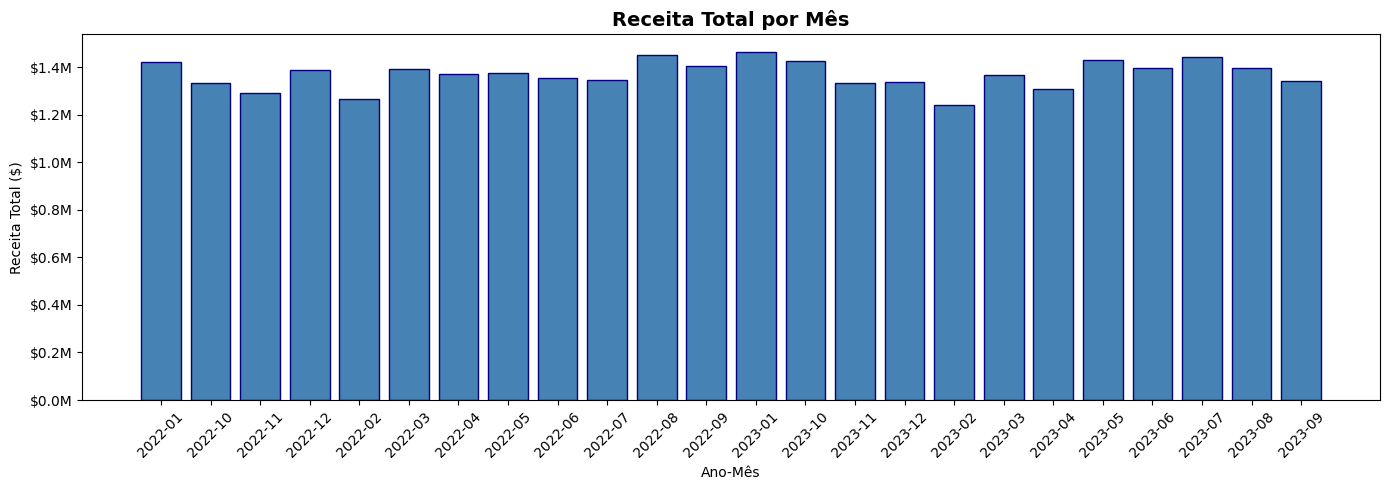

In [19]:
fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(v_receita['ano_mes'], v_receita['receita_total'], color='steelblue', edgecolor='navy')
ax.set_title('Receita Total por Mês', fontsize=14, fontweight='bold')
ax.set_xlabel('Ano-Mês')
ax.set_ylabel('Receita Total ($)')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
plt.tight_layout()
plt.show()

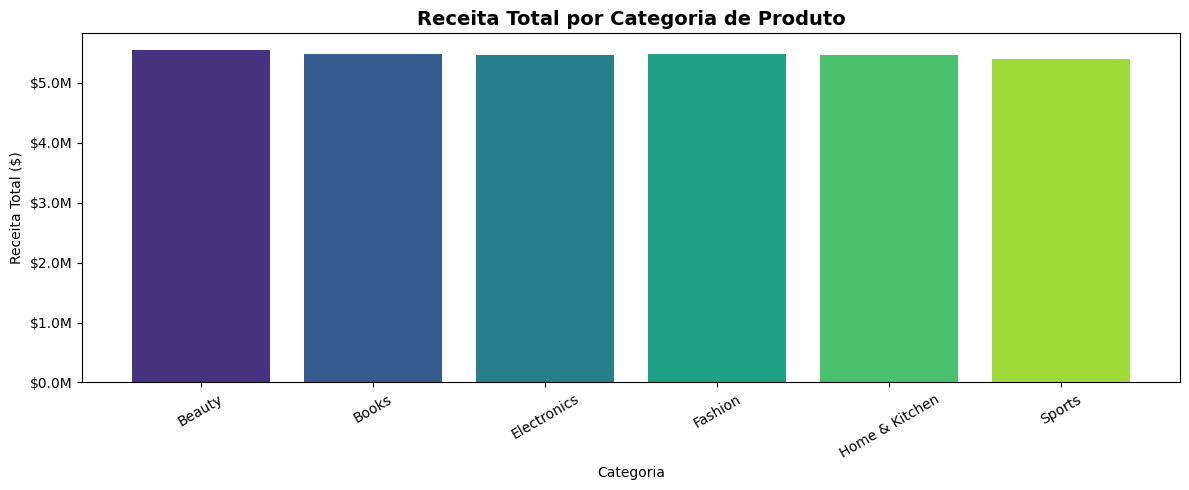

In [20]:
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(v_categoria['product_category'], v_categoria['receita_total'], color=sns.color_palette('viridis', len(v_categoria)))
ax.set_title('Receita Total por Categoria de Produto', fontsize=14, fontweight='bold')
ax.set_xlabel('Categoria')
ax.set_ylabel('Receita Total ($)')
ax.tick_params(axis='x', rotation=30)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
plt.tight_layout()
plt.show()

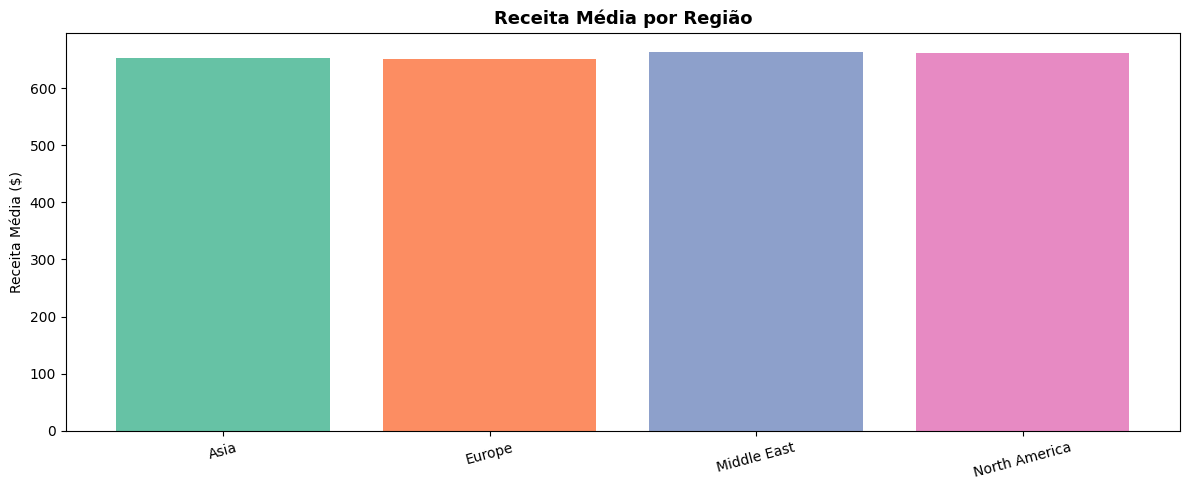

In [21]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(v_regiao['customer_region'], v_regiao['receita_media'], color=sns.color_palette('Set2', len(v_regiao)))
ax.set_title('Receita Média por Região', fontsize=13, fontweight='bold')
ax.set_ylabel('Receita Média ($)')
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

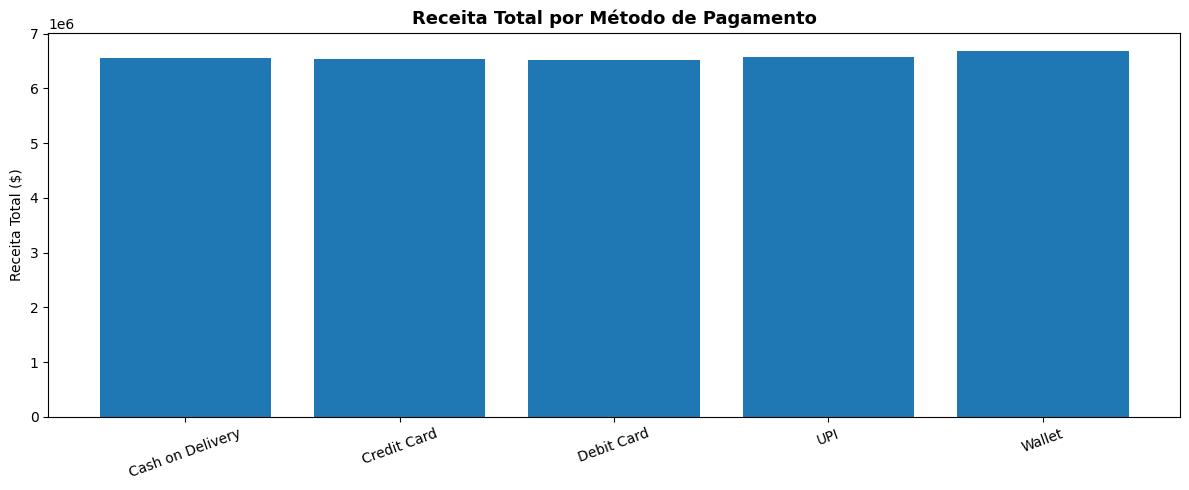

In [22]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(v_pagamento['payment_method'], v_pagamento['receita_total'])
ax.set_title('Receita Total por Método de Pagamento', fontsize=13, fontweight='bold')
ax.set_ylabel('Receita Total ($)')
ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()